# Problem Statement

**Predict product demand using pricing, promotions, and seasonal factors to help optimize inventory and revenue planning.**




## Business Objective

The goal of this project is to predict product demand to help optimize inventory levels, reduce stockouts, and improve revenue forecasting.

Accurate demand prediction allows:
- Better inventory planning
- Reduced holding costs
- Improved pricing strategy

In [175]:
import pandas as pd
train = pd.read_csv('train.csv')
train.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [176]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [177]:
train.describe()

,store,item,sales
count,913000.000000,913000.000000,913000.000000
mean,5.500000,25.500000,52.250287
std,2.872283,14.430878,28.801144
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,70.000000
max,10.000000,50.000000,231.000000


In [178]:
test = pd.read_csv('test.csv')
test.head()

,id,date,store,item
0,0,2018-01-01,1,1
1,1,2018-01-02,1,1
2,2,2018-01-03,1,1
3,3,2018-01-04,1,1
4,4,2018-01-05,1,1


In [179]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      45000 non-null  int64 
 1   date    45000 non-null  object
 2   store   45000 non-null  int64 
 3   item    45000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.4+ MB


In [180]:
test.describe()

,id,store,item
count,45000.000000,45000.000000,45000.00000
mean,22499.500000,5.500000,25.50000
std,12990.525394,2.872313,14.43103
min,0.000000,1.000000,1.00000
25%,11249.750000,3.000000,13.00000
50%,22499.500000,5.500000,25.50000
75%,33749.250000,8.000000,38.00000
max,44999.000000,10.000000,50.00000


In [181]:
train.shape

(913000, 4)

In [182]:
test.shape

(45000, 4)

After looking at the data, it looks like we have 3 input variable -> [date, store, item] and our target Variable is -> [Sales]. Lets do some feature engineering on them.

In [183]:
train['date'] = pd.to_datetime(train['date'])
train = train.sort_values(['store', 'item', 'date'])

In [184]:
lags = [1, 7, 30]
for lag in lags:
    # lag_sales_1: What you sold yesterday, lag_sales_7: What you sold exactly one week ago (the same day of the week) single snapshot, lag_sales_30: What you sold one month ago.
    train[f'lag_sales_{lag}'] = train.groupby(['store', 'item'])['sales'].shift(lag)

# 7-day and 30-day windows are most common for retail
#For every single day in your data, you have a number representing "How well did we do over the last 7 days?" Adding up sales from the last 7 days and dividing by 7. If you sold 10, 12, 10, 11, 9, 10, and 12, your mean is 10.5.
train['rolling_mean_7'] = train.groupby(['store', 'item'])['sales'] \
                         .transform(lambda x: x.rolling(window=7, min_periods=1).mean())
#For every single day in your data, you have a number representing "How well did we do over the last 30 days?"
train['rolling_mean_30'] = train.groupby(['store', 'item'])['sales'] \
                          .transform(lambda x: x.rolling(window=30, min_periods=1).mean())
# Calculate rolling standard deviation (How spread the data is for a week, if it is smooth or bumpy, if this is low that means sales are steady and predictable, if high means maybe bursty or some promotions or holiday.)
train['rolling_std_7'] = train.groupby(['store', 'item'])['sales'] \
                        .transform(lambda x: x.rolling(window=7, min_periods=1).std())

# Flag as promo if sales > (Rolling Mean + 1.5 * Rolling Std)
train['is_promotion'] = (train['sales'] > (train['rolling_mean_7'] + 1.5 * train['rolling_std_7'])).astype(int)
train.dropna(inplace=True)
train

,date,store,item,sales,lag_sales_1,lag_sales_7,lag_sales_30,rolling_mean_7,rolling_mean_30,rolling_std_7,is_promotion
30,2013-01-31,1,1,13,9.0,8.0,13.0,11.000000,10.500000,2.708013,0
31,2013-02-01,1,1,11,13.0,14.0,11.0,10.571429,10.500000,2.370453,0
32,2013-02-02,1,1,21,11.0,12.0,14.0,11.857143,10.733333,4.634241,1
33,2013-02-03,1,1,15,21.0,12.0,13.0,12.285714,10.800000,4.785892,0
34,2013-02-04,1,1,14,15.0,11.0,10.0,12.714286,10.933333,4.785892,0
...,...,...,...,...,...,...,...,...,...,...,...
912995,2017-12-27,10,50,63,41.0,51.0,75.0,62.714286,64.233333,12.841525,0
912996,2017-12-28,10,50,59,63.0,63.0,68.0,62.142857,63.933333,12.915476,0
912997,2017-12-29,10,50,74,59.0,75.0,76.0,62.000000,63.866667,12.754084,0
912998,2017-12-30,10,50,62,74.0,70.0,73.0,60.857143,63.500000,12.266874,0


In [185]:
Y_train = train['sales']
X_train = train.drop('sales', axis = 1)

In [186]:
import holidays
years = X_train['date'].dt.year.unique()
years
holi = []
for h in holidays.UnitedStates(years=years).items():
  holi.append(h[0])
holi
holiday_set = set(holi)
holiday_set

{datetime.date(2013, 1, 1),
 datetime.date(2013, 1, 21),
 datetime.date(2013, 2, 18),
 datetime.date(2013, 5, 27),
 datetime.date(2013, 7, 4),
 datetime.date(2013, 9, 2),
 datetime.date(2013, 10, 14),
 datetime.date(2013, 11, 11),
 datetime.date(2013, 11, 28),
 datetime.date(2013, 12, 25),
 datetime.date(2014, 1, 1),
 datetime.date(2014, 1, 20),
 datetime.date(2014, 2, 17),
 datetime.date(2014, 5, 26),
 datetime.date(2014, 7, 4),
 datetime.date(2014, 9, 1),
 datetime.date(2014, 10, 13),
 datetime.date(2014, 11, 11),
 datetime.date(2014, 11, 27),
 datetime.date(2014, 12, 25),
 datetime.date(2015, 1, 1),
 datetime.date(2015, 1, 19),
 datetime.date(2015, 2, 16),
 datetime.date(2015, 5, 25),
 datetime.date(2015, 7, 3),
 datetime.date(2015, 7, 4),
 datetime.date(2015, 9, 7),
 datetime.date(2015, 10, 12),
 datetime.date(2015, 11, 11),
 datetime.date(2015, 11, 26),
 datetime.date(2015, 12, 25),
 datetime.date(2016, 1, 1),
 datetime.date(2016, 1, 18),
 datetime.date(2016, 2, 15),
 datetime.dat

In [187]:
X_train['month'] = X_train['date'].dt.month
X_train['daysofweek'] = X_train['date'].dt.dayofweek
X_train['isWeekend'] = X_train['date'].dt.dayofweek > 4
X_train['isHoliday'] = X_train['date'].isin(holiday_set)
X_train

/tmp/ipython-input-617757616.py:4: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  X_train['isHoliday'] = X_train['date'].isin(holiday_set)


,date,store,item,lag_sales_1,lag_sales_7,lag_sales_30,rolling_mean_7,rolling_mean_30,rolling_std_7,is_promotion,month,daysofweek,isWeekend,isHoliday
30,2013-01-31,1,1,9.0,8.0,13.0,11.000000,10.500000,2.708013,0,1,3,False,False
31,2013-02-01,1,1,13.0,14.0,11.0,10.571429,10.500000,2.370453,0,2,4,False,False
32,2013-02-02,1,1,11.0,12.0,14.0,11.857143,10.733333,4.634241,1,2,5,True,False
33,2013-02-03,1,1,21.0,12.0,13.0,12.285714,10.800000,4.785892,0,2,6,True,False
34,2013-02-04,1,1,15.0,11.0,10.0,12.714286,10.933333,4.785892,0,2,0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
912995,2017-12-27,10,50,41.0,51.0,75.0,62.714286,64.233333,12.841525,0,12,2,False,False
912996,2017-12-28,10,50,63.0,63.0,68.0,62.142857,63.933333,12.915476,0,12,3,False,False
912997,2017-12-29,10,50,59.0,75.0,76.0,62.000000,63.866667,12.754084,0,12,4,False,False
912998,2017-12-30,10,50,74.0,70.0,73.0,60.857143,63.500000,12.266874,0,12,5,True,False


In [188]:
X_train.isnull().sum()

,0
date,0
store,0
item,0
lag_sales_1,0
lag_sales_7,0
lag_sales_30,0
rolling_mean_7,0
rolling_mean_30,0
rolling_std_7,0
is_promotion,0


Now lets dig into the behaviour and nature of data performing EDA

<Axes: xlabel='store', ylabel='sales'>

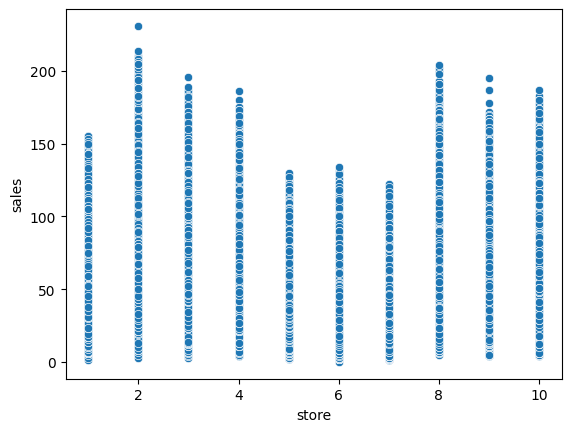

In [189]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x = X_train['store'], y = Y_train)

<Axes: xlabel='store', ylabel='sales'>

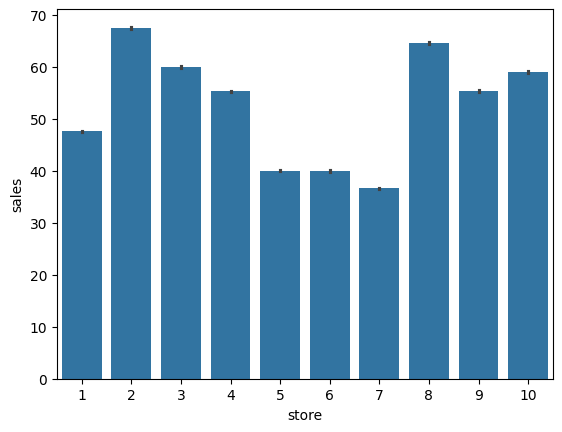

In [190]:
sns.barplot(x = X_train['store'], y = Y_train)

Looks like highest sale is from Store2 and lowest is from Store 7. Lets test it out if our assumption is correct.

In [191]:
X_train['store'].value_counts()

,count
store,
1,89800
2,89800
3,89800
4,89800
5,89800
6,89800
7,89800
8,89800
9,89800


In [192]:
Store_2 = X_train[X_train['store'] == 2]
Store_2_rolling_30 = Store_2['rolling_mean_30'].sum()/Store_2.shape[0]
Store_2_rolling_30

np.float64(67.35748626577579)

In [193]:
Store_7 = X_train[X_train['store'] == 7]
Store_7_rolling_30 = Store_7['rolling_mean_30'].sum()/Store_7.shape[0]
Store_7_rolling_30

np.float64(36.54198144023757)

Store 2 typically sells about 70 items per day, whereas Store 7 sells about 37 items per day on a rolling monthly basis. Store 2 is 1.8 times larger in volume than Store 7

<Axes: xlabel='item', ylabel='sales'>

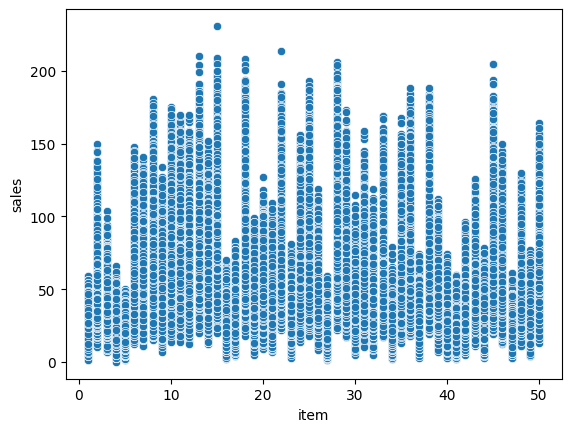

In [194]:
sns.scatterplot(x = X_train['item'], y = Y_train)

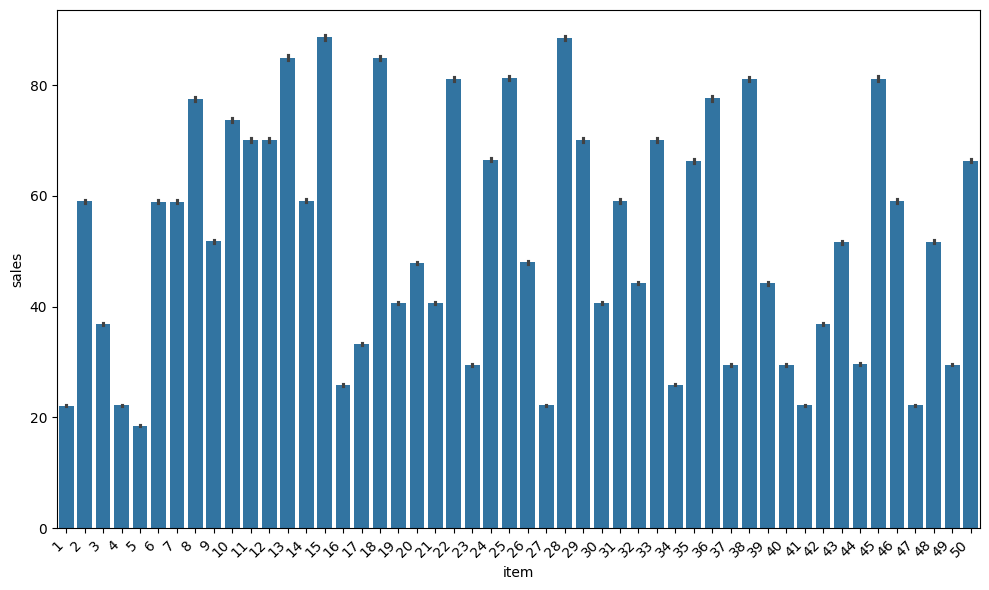

In [195]:
plt.figure(figsize=(10, 6))
sns.barplot(x = X_train['item'], y = Y_train,)
plt.xticks(fontsize=10, rotation=45, ha='right')
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

Seems like highest item ID sold is 15 over the years from 2013 to 2017.

In [196]:
Item_15 = X_train[X_train['item'] == 15]
Item_15_rolling_30 = Item_15['rolling_mean_30'].sum()/Item_15.shape[0]
Item_15_rolling_30

np.float64(88.46389198218263)

Average performance for Item ID 15 is 88 per day on a rolling monthly basis.


<Axes: xlabel='date', ylabel='sales'>

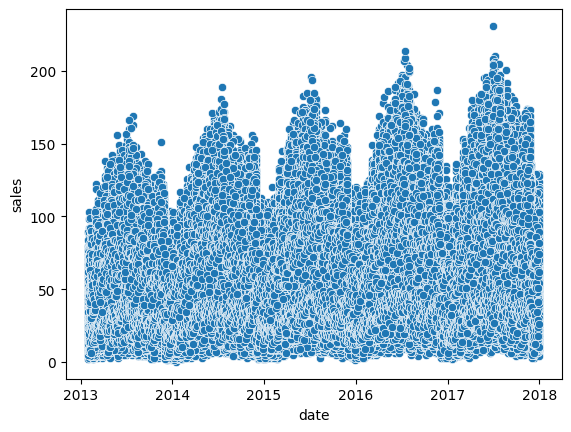

In [197]:
sns.scatterplot(x = X_train['date'], y = Y_train)

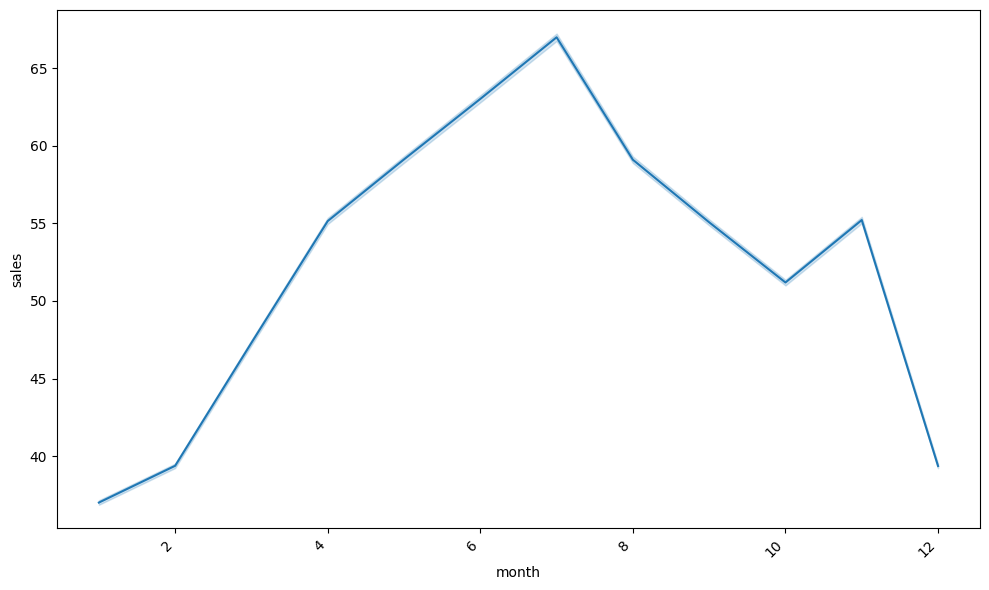

In [198]:
plt.figure(figsize=(10, 6))
sns.lineplot(x = X_train['month'], y = Y_train)
plt.xticks(fontsize=10, rotation=45, ha='right')
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

Looks like July has most of Sales, it might be because of 4th July promotions/discounts and than we have a surge in sales in November, it can be because of Black Friday. Now lets see do some bivariate analysis and multivariate analysis to deep dive into the data.


1st Analysis: Yesterday's sale was affected by holiday or weekend
2nd Analysis: What does sale looks like over the last 7 days, Is it a smooth sale?, Was it because of promotion?
3rd Analysis: Which month, and which days of week have the highest and lowest sale? Why?

<Axes: xlabel='item', ylabel='sales'>

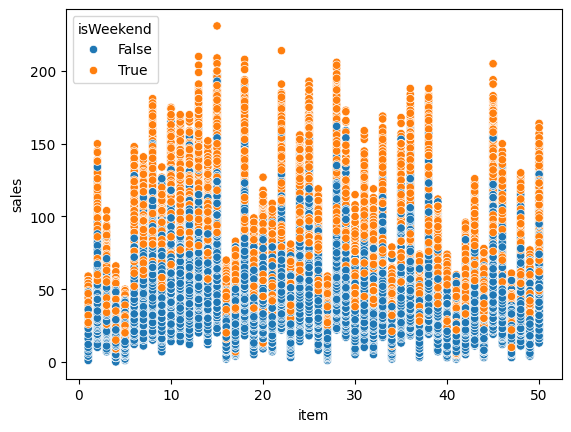

In [199]:

sns.scatterplot(x=X_train['item'], y=Y_train, hue=X_train['isWeekend'])

<Axes: xlabel='item', ylabel='sales'>

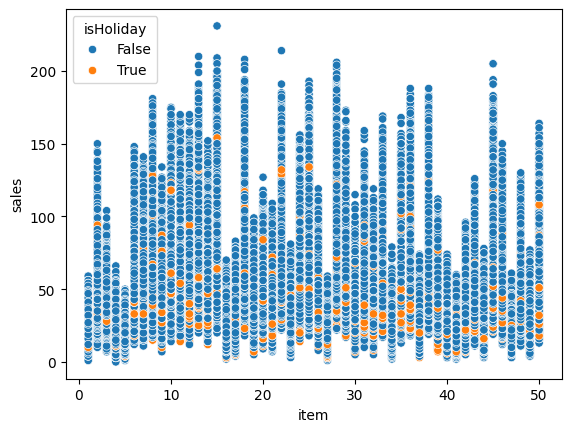

In [200]:
sns.scatterplot(x=X_train['item'], y=Y_train, hue=X_train['isHoliday'])

<Axes: xlabel='store', ylabel='sales'>

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


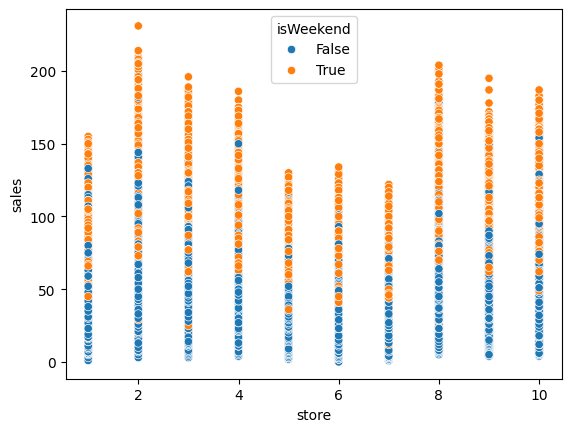

In [201]:
sns.scatterplot(x=X_train['store'], y=Y_train, hue=X_train['isWeekend'])

<Axes: xlabel='store', ylabel='sales'>

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


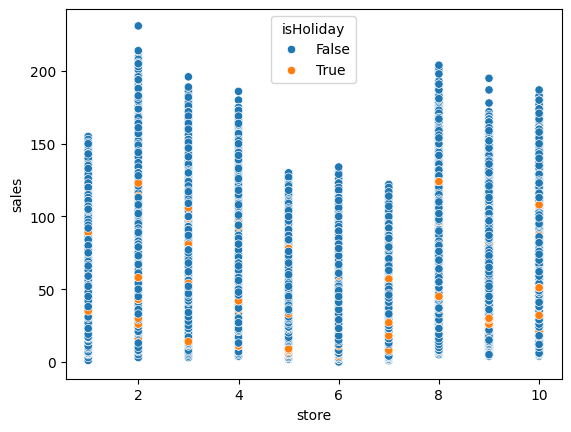

In [202]:
sns.scatterplot(x=X_train['store'], y=Y_train, hue=X_train['isHoliday'])

<Axes: xlabel='isHoliday', ylabel='lag_sales_1'>

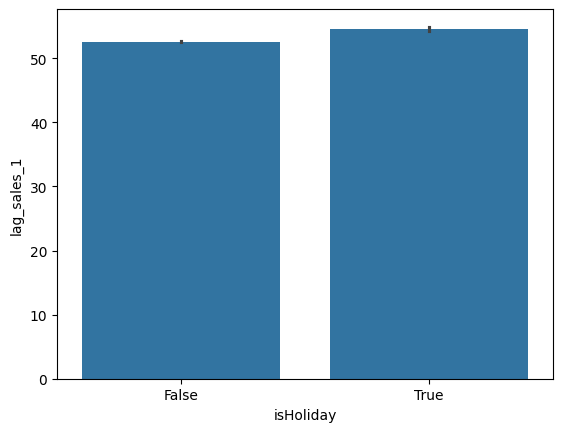

In [203]:
sns.barplot(x=X_train['isHoliday'], y=X_train['lag_sales_1'])

In [204]:
Holidays = X_train[X_train['isHoliday'] == True]
Yesterday_Holiday = Holidays['lag_sales_1'].sum()/Holidays.shape[0]
Yesterday_Holiday

np.float64(54.555692307692304)

<Axes: xlabel='isWeekend', ylabel='lag_sales_1'>

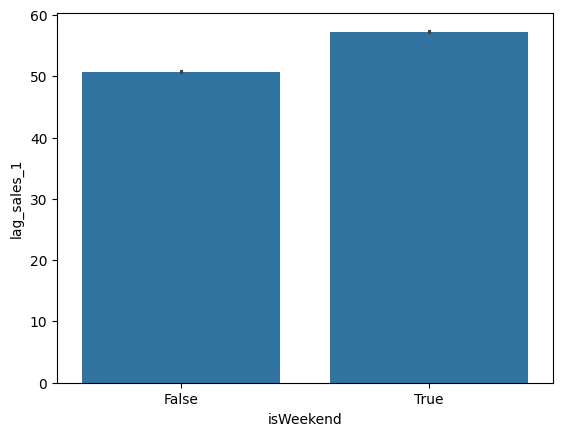

In [205]:
sns.barplot(x=X_train['isWeekend'], y=X_train['lag_sales_1'])

In [206]:
Weekends = X_train[X_train['isWeekend'] == True]
Yesterday_Weekend = Weekends['lag_sales_1'].sum()/Weekends.shape[0]
Yesterday_Weekend

np.float64(57.29683657587549)

Yup it looks like Yesterday's sale was affected more by holiday or weekend. If today is Holiday sales from yesterday averaged 54 Items, on weekends, yesterdays sales averaged 57 items. Although weekend average is higher than Holiday average that means people buy more when weekends approach.

In [207]:
Store_2_Item_15 = Store_2[Store_2['item'] == 15]

In [208]:
Store_7_Item_5 = Store_7[Store_7['item'] == 5]

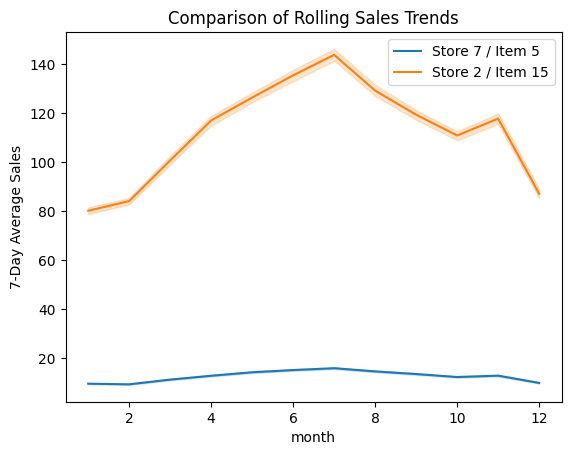

In [209]:
sns.lineplot(x = Store_7_Item_5['month'], y = Store_7_Item_5['rolling_mean_7'], label = 'Store 7 / Item 5' )
sns.lineplot(data = Store_2_Item_15, x = 'month', y = 'rolling_mean_7', label = 'Store 2 / Item 15')
plt.title('Comparison of Rolling Sales Trends')
plt.ylabel('7-Day Average Sales')
plt.legend()
plt.show()

In [210]:
Store2_Item15_Rolling_7 = Store_2_Item_15['rolling_mean_7'].sum()/Store_2_Item_15.shape[0]
Store2_Item15_Rolling_7

np.float64(113.32731466751513)

In [211]:
Store7_Item5_Rolling_7 = Store_7_Item_5['rolling_mean_7'].sum()/Store_7_Item_5.shape[0]
Store7_Item5_Rolling_7

np.float64(12.827553293032135)

In [212]:
Store_2_Item_15['rolling_std_7'].mean()

np.float64(18.660229795241367)

In [213]:
Store_7_Item_5['rolling_std_7'].mean()

np.float64(3.8604766816159484)

7 day rolling sales for Store 2 Item 15 is 9.5 times Store 7 Item 5. But if you look at the spread sales over 7 day Store 8 for Item 5 have steady sellers (low std) than Store 2 for Item 15. It can be because of Promotions

In [214]:
Store_7_Item_15 = Store_7[Store_7['item'] == 15]

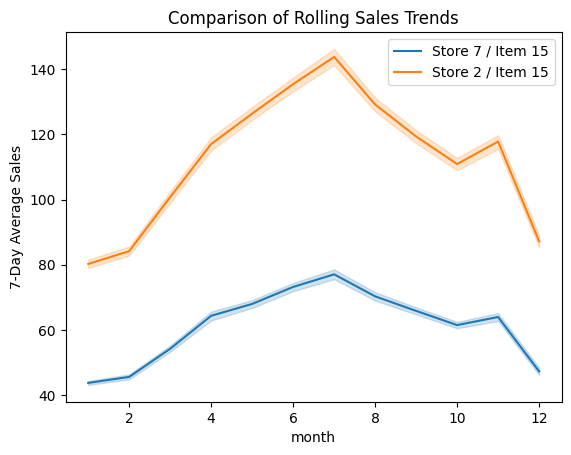

In [215]:
sns.lineplot(x = Store_7_Item_15['month'], y = Store_7_Item_15['rolling_mean_7'], label = 'Store 7 / Item 15' )
sns.lineplot(data = Store_2_Item_15, x = 'month', y = 'rolling_mean_7', label = 'Store 2 / Item 15')
plt.title('Comparison of Rolling Sales Trends')
plt.ylabel('7-Day Average Sales')
plt.legend()
plt.show()

In [216]:
Store_7_Item_15['rolling_mean_7'].mean()

np.float64(61.57548520521794)

In [217]:
Store_7_Item_15['rolling_std_7'].mean()

np.float64(10.972209936990406)

/tmp/ipython-input-1744052348.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


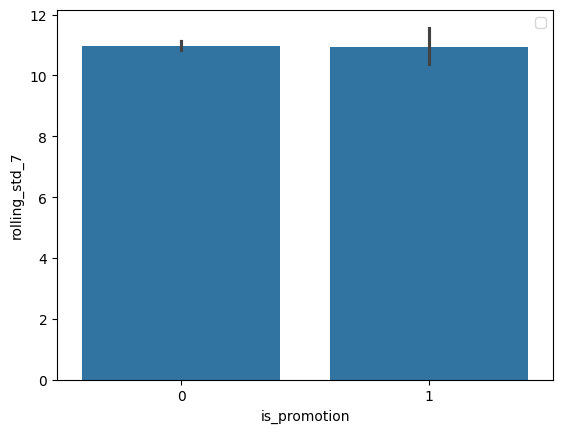

In [218]:
sns.barplot(x = Store_7_Item_15['is_promotion'], y = Store_7_Item_15['rolling_std_7'])
plt.legend()
plt.show()

<Axes: xlabel='is_promotion', ylabel='rolling_std_7'>

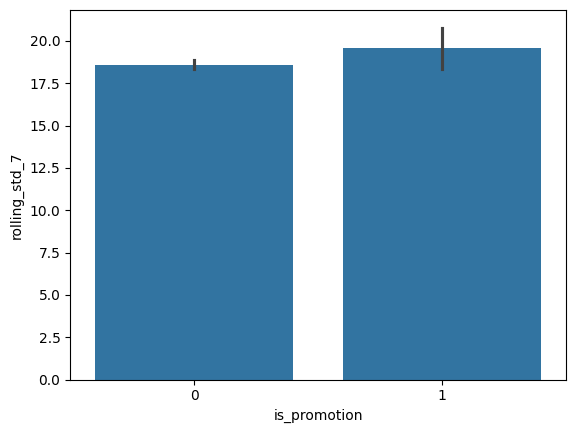

In [219]:
sns.barplot(data = Store_2_Item_15, x = 'is_promotion', y = 'rolling_std_7' )

7 day rolling sales for Store 2 Item 15 is 1.85 times Store 7 Item 15. Looks like Item 15 is high impact Item (high std) that is sold due to Promotion

In [220]:
Store_2_Item_5 = Store_2[Store_2['item'] == 5]

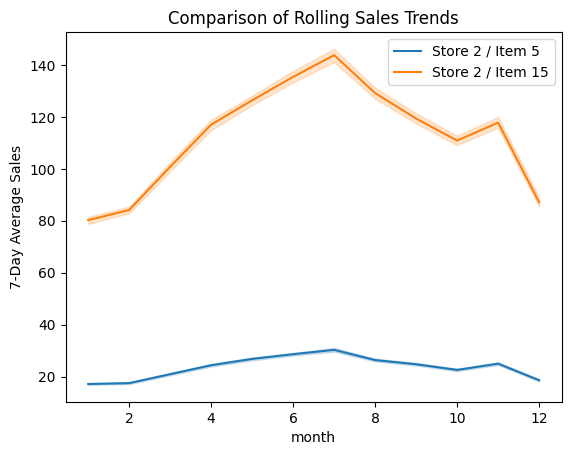

In [221]:
sns.lineplot(x = Store_2_Item_5['month'], y = Store_2_Item_5['rolling_mean_7'], label = 'Store 2 / Item 5' )
sns.lineplot(data = Store_2_Item_15, x = 'month', y = 'rolling_mean_7', label = 'Store 2 / Item 15')
plt.title('Comparison of Rolling Sales Trends')
plt.ylabel('7-Day Average Sales')
plt.legend()
plt.show()

In [222]:
Store_2_Item_5['rolling_mean_7'].mean()

np.float64(23.69957047406936)

In [223]:
Store_2_Item_5['rolling_std_7'].mean()

np.float64(5.832731621725991)

7 day rolling sales for Store 2 Item 15 is 5 times Store 2 Item 5. But if you look at the spread sales over 7 day both Store 2 and 7 for Item 5 have steady sellers (low std) than Item 15.
"I compared different store-item combinations and found that while the volume (scale) varies significantly, the seasonal profile (shape) is consistent across the catalog. This suggests that 'Month' and 'Day of Week' will be high-importance features for the model."

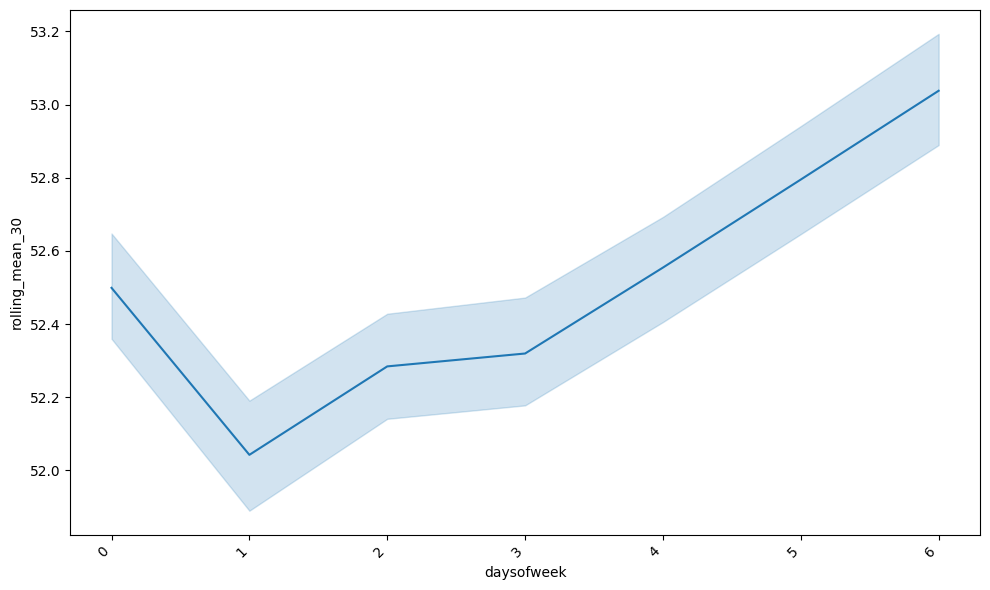

In [224]:
plt.figure(figsize=(10, 6))
sns.lineplot(x = X_train['daysofweek'], y = X_train['rolling_mean_30'])
plt.xticks(fontsize=10, rotation=45, ha='right')
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

30 Days rolling Sale strictly surges after Thursday, that means inflation in sale occurs near to weekends and during weekends which also supports our previous analysis. This might be due to people felt convenience when they shop near the weekends as they are busy in weekdays

Lets apply Linear Regression

In [225]:
from sklearn.linear_model import LinearRegression

In [226]:
slr_X = X_train.drop(['lag_sales_1',	'lag_sales_7',	'lag_sales_30',	'rolling_mean_7',	'rolling_mean_30'	,'rolling_std_7',	'is_promotion',	'month',	'daysofweek',	'isWeekend','isHoliday', 'date'], axis = 'columns')

In [227]:
from sklearn.model_selection import train_test_split
X_train_slr,X_test_slr,y_train_slr,y_test_slr = train_test_split(slr_X,Y_train,test_size=0.2,random_state=2)

In [228]:
slr = LinearRegression()

In [229]:
slr.fit(X_train_slr, y_train_slr)

LinearRegression()

In [230]:
y_pred_slr = slr.predict(X_test_slr)

In [231]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [235]:
#print("RMSE for train",np.sqrt(mean_squared_error(y_train_slr,slr.predict(X_train_slr))))
print("RMSE for test",np.sqrt(mean_squared_error(y_test_slr,y_pred_slr)))

RMSE for test 28.812593650067782


In [236]:
r2_score(y_test_slr,y_pred_slr)

0.0033819822247398434

Since R2 Score is 0.003 it is a classic example of underfitting. Lets try Multiple Linear Regression.

In [237]:
# Filter for just one specific time series
Segmentation = train[(train['store'] == 2) & (train['item'] == 15)]

X = Segmentation.drop(['sales', 'date'], axis=1)
y = Segmentation['sales']

# Re-run Linear Regression on just this
slr.fit(X, y)
print(slr.score(X, y)) # This R2 should be MUCH higher (likely > 0.70)

0.7975643738674647


"Initially, my global Simple Linear Regression model had an \R2 near zero. I performed a segmentation test on a single Store-Item pair and found the R2 jumped to 0.79. This proved that my lagged and rolling features are highly predictive, but the global model was failing because it couldn't account for the different sales scales (baselines) across 500 different products." Let dive deep into Multiple Linear Regression.

In [238]:
lr = LinearRegression()

In [239]:
X_train_except_date = X_train.drop('date', axis='columns') # Keep all engineered features except 'date'
X_train_except_date

,store,item,lag_sales_1,lag_sales_7,lag_sales_30,rolling_mean_7,rolling_mean_30,rolling_std_7,is_promotion,month,daysofweek,isWeekend,isHoliday
30,1,1,9.0,8.0,13.0,11.000000,10.500000,2.708013,0,1,3,False,False
31,1,1,13.0,14.0,11.0,10.571429,10.500000,2.370453,0,2,4,False,False
32,1,1,11.0,12.0,14.0,11.857143,10.733333,4.634241,1,2,5,True,False
33,1,1,21.0,12.0,13.0,12.285714,10.800000,4.785892,0,2,6,True,False
34,1,1,15.0,11.0,10.0,12.714286,10.933333,4.785892,0,2,0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
912995,10,50,41.0,51.0,75.0,62.714286,64.233333,12.841525,0,12,2,False,False
912996,10,50,63.0,63.0,68.0,62.142857,63.933333,12.915476,0,12,3,False,False
912997,10,50,59.0,75.0,76.0,62.000000,63.866667,12.754084,0,12,4,False,False
912998,10,50,74.0,70.0,73.0,60.857143,63.500000,12.266874,0,12,5,True,False


In [240]:
Y_train

,sales
30,13
31,11
32,21
33,15
34,14
...,...
912995,63
912996,59
912997,74
912998,62


In [241]:
from sklearn.model_selection import train_test_split
import numpy as np
X_train,X_test,y_train,y_test = train_test_split(X_train_except_date,Y_train,test_size=0.2,random_state=2)

In [242]:
lr.fit(X_train, y_train)

LinearRegression()

In [243]:
y_pred = lr.predict(X_test)
y_pred

array([37.88219869, 40.18861806, 47.26630096, ..., 56.82010904,
       56.96827367, 41.42246886])

In [244]:
print("MAE",mean_absolute_error(y_test,y_pred))

MAE 5.552254415372766


In [245]:
print("MSE",mean_squared_error(y_test,y_pred))

MSE 51.7160857568376


In [246]:
print("RMSE for train",np.sqrt(mean_squared_error(y_train,lr.predict(X_train))))

RMSE for train 7.1940777657300465


In [247]:
print("RMSE for test",np.sqrt(mean_squared_error(y_test,y_pred)))

RMSE for test 7.191389695798553


In [248]:
y_train.std()

28.810658405226913

The training RMSE of 7.19 is significantly lower than the natural volatility of the sales data, confirming that our features are successfully capturing the underlying demand signal.
My Train RMSE is 7.194 and my Test RMSE is 7.191. The fact that these numbers are nearly identical—and that the test error did not increase—is strong empirical evidence that the model is not overfitting. It has learned the general patterns of the data rather than just memorizing the training samples.
Multiple regression reduced RMSE by 24%, indicating additional features improved predictive performance.”

In [249]:
r2 = r2_score(y_test,y_pred)
r2

0.9379145729457112

In [250]:
1 - (1-r2)*(len(y_train)-1)/(len(y_train)-X_train.shape[1]-1)

0.9379134494403093

In [251]:
lr.coef_.shape

(13,)

In [252]:
X_train

,store,item,lag_sales_1,lag_sales_7,lag_sales_30,rolling_mean_7,rolling_mean_30,rolling_std_7,is_promotion,month,daysofweek,isWeekend,isHoliday
582865,10,32,26.0,32.0,32.0,32.000000,31.866667,8.869423,0,1,1,False,False
577771,7,32,23.0,18.0,21.0,21.000000,20.733333,4.690416,0,1,0,False,False
368140,2,21,44.0,34.0,31.0,42.857143,38.733333,8.764104,0,1,2,False,False
179776,9,10,81.0,90.0,81.0,87.428571,75.666667,13.023788,0,4,3,False,False
87159,8,5,23.0,30.0,41.0,28.000000,27.166667,5.537749,0,8,1,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
793868,5,44,36.0,24.0,31.0,26.000000,26.800000,5.163978,0,10,6,True,False
833170,7,46,51.0,50.0,42.0,43.714286,43.300000,6.156684,0,5,4,False,False
241359,3,14,59.0,59.0,61.0,56.428571,55.500000,11.487053,0,11,6,True,False
111719,2,7,71.0,76.0,71.0,63.428571,66.700000,6.051367,0,11,5,True,False


Lets do one hot encoding and see if it changes the R2 Score at all.

In [253]:
# Convert to dummies for 'store', 'item', 'isWeekend', and 'isHoliday'
# Ensure consistency with how test features will be created.
X_train_final = pd.get_dummies(X_train, columns=['store', 'item', 'isWeekend', 'isHoliday'], drop_first=True)
X_test_final = pd.get_dummies(X_test, columns=['store', 'item', 'isWeekend', 'isHoliday'], drop_first=True)

# Re-run the global model
rerun = lr.fit(X_train_final, y_train)

In [254]:
y_pred = rerun.predict(X_test_final)

In [255]:
r2 = r2_score(y_test, y_pred)
r2

0.9379132724162096

R2 Score is 0.93, and hence multiple regression outperforms simple linear regression. Now lets test it on real data, also lets engineer the features in test and predict the sales for real test data.

In [256]:
# 1. Feature Engineer the real test data the SAME way (lags, rolling, holidays, etc.)
# This involves calculating date features and initializing lag/rolling features from the end of the training data.
test['date'] = pd.to_datetime(test['date'])
# Create date-based features for 'test'
test['month'] = test['date'].dt.month
test['daysofweek'] = test['date'].dt.dayofweek
test['isWeekend'] = test['date'].dt.dayofweek > 4
test['isHoliday'] = test['date'].isin(holiday_set)

# To correctly initialize lags and rolling features for the test set (2018),
# we need the last values from the training set (2017).
# For simplicity, we'll create a combined dataset for calculating these.
# A more robust solution might involve specialized time-series feature engineering libraries.

# Get last few days of train for each store-item combo to act as history for test's initial features
# Need enough history for 30-day lags and rolling features.
# Let's take the last 30 days of `train` data for each store-item pair.
last_train_history = train.groupby(['store', 'item']).tail(30).copy()

# Add a temporary 'sales' column to `test` for feature calculation (will be dropped later for prediction)
test['sales'] = 0 # Placeholder for sales in test data

# Concatenate last_train_history and test for feature generation
# Ensure `test` has the same columns for concatenation (minus 'id' for now, add back later)
combined_df = pd.concat([last_train_history, test.drop(columns=['id'])], ignore_index=True)

# Sort the combined DataFrame to ensure correct lag and rolling calculations
combined_df = combined_df.sort_values(['store', 'item', 'date']).reset_index(drop=True)

# Recompute lags and rolling features for the combined dataset
lags = [1, 7, 30]
for lag in lags:
    combined_df[f'lag_sales_{lag}'] = combined_df.groupby(['store', 'item'])['sales'].shift(lag)

combined_df['rolling_mean_7'] = combined_df.groupby(['store', 'item'])['sales'].transform(lambda x: x.rolling(window=7, min_periods=1).mean())
combined_df['rolling_mean_30'] = combined_df.groupby(['store', 'item'])['sales'].transform(lambda x: x.rolling(window=30, min_periods=1).mean())
combined_df['rolling_std_7'] = combined_df.groupby(['store', 'item'])['sales'].transform(lambda x: x.rolling(window=7, min_periods=1).std())
combined_df['is_promotion'] = (combined_df['sales'] > (combined_df['rolling_mean_7'] + 1.5 * combined_df['rolling_std_7'])).astype(int)

# Extract the features for the 'test' portion by filtering dates > max date in train
max_train_date = train['date'].max()
engineered_test_features = combined_df[combined_df['date'] > max_train_date].copy()

# Drop the temporary 'sales' column from engineered_test_features
engineered_test_features = engineered_test_features.drop(columns=['sales'])

# Merge engineered features back to the original `test` DataFrame, keeping 'id'
# This requires setting the index or merging on multiple keys
test_merged = test.drop(columns=['month', 'daysofweek', 'isWeekend', 'isHoliday', 'sales'])
real_test_final_df = pd.merge(test_merged, engineered_test_features, on=['date', 'store', 'item'], how='left')

# Fill any NaNs that might result from initial lag/rolling calculations at the very start of the test set
# (e.g., if a rolling window requires more history than available from train_end for a specific item/store)
# A common strategy is to fill with 0 or the mean of the feature from the training data.
real_test_final_df = real_test_final_df.fillna(0)

# Now, apply get_dummies and reindex to match X_train_final
real_test_encoded = pd.get_dummies(real_test_final_df.drop(columns=['id', 'date']), columns=['store', 'item', 'isWeekend', 'isHoliday'], drop_first=True)

# Ensure columns match X_train_final perfectly
real_test_final = real_test_encoded.reindex(columns=X_train_final.columns, fill_value=0)

/tmp/ipython-input-1552752121.py:8: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  test['isHoliday'] = test['date'].isin(holiday_set)
/tmp/ipython-input-1552752121.py:55: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  real_test_final_df = real_test_final_df.fillna(0)


In [257]:
real_predictions = lr.predict(real_test_final)

# Add them to your test dataframe for viewing
test['predicted_sales'] = real_predictions

In [258]:
test

,id,date,store,item,month,daysofweek,isWeekend,isHoliday,sales,predicted_sales
0,0,2018-01-01,1,1,1,0,False,False,0,7.222003
1,1,2018-01-02,1,1,1,1,False,False,0,9.659534
2,2,2018-01-03,1,1,1,2,False,False,0,9.338599
3,3,2018-01-04,1,1,1,3,False,False,0,9.734309
4,4,2018-01-05,1,1,1,4,False,False,0,9.262279
...,...,...,...,...,...,...,...,...,...,...
44995,44995,2018-03-27,10,50,3,1,False,False,0,-4.596445
44996,44996,2018-03-28,10,50,3,2,False,False,0,-2.159447
44997,44997,2018-03-29,10,50,3,3,False,False,0,0.277551
44998,44998,2018-03-30,10,50,3,4,False,False,0,2.714549


In [259]:
test.describe()

,id,date,store,item,month,daysofweek,sales,predicted_sales
count,45000.000000,45000,45000.000000,45000.00000,45000.000000,45000.000000,45000.0,45000.000000
mean,22499.500000,2018-02-14 12:00:00.000000256,5.500000,25.50000,2.000000,2.966667,0.0,1.010417
min,0.000000,2018-01-01 00:00:00,1.000000,1.00000,1.000000,0.000000,0.0,-18.892420
25%,11249.750000,2018-01-23 00:00:00,3.000000,13.00000,1.000000,1.000000,0.0,-4.700819
50%,22499.500000,2018-02-14 12:00:00,5.500000,25.50000,2.000000,3.000000,0.0,0.053974
75%,33749.250000,2018-03-09 00:00:00,8.000000,38.00000,3.000000,5.000000,0.0,5.042660
max,44999.000000,2018-03-31 00:00:00,10.000000,50.00000,3.000000,6.000000,0.0,74.498967
std,12990.525394,NaN,2.872313,14.43103,0.830003,1.985805,0.0,8.605587


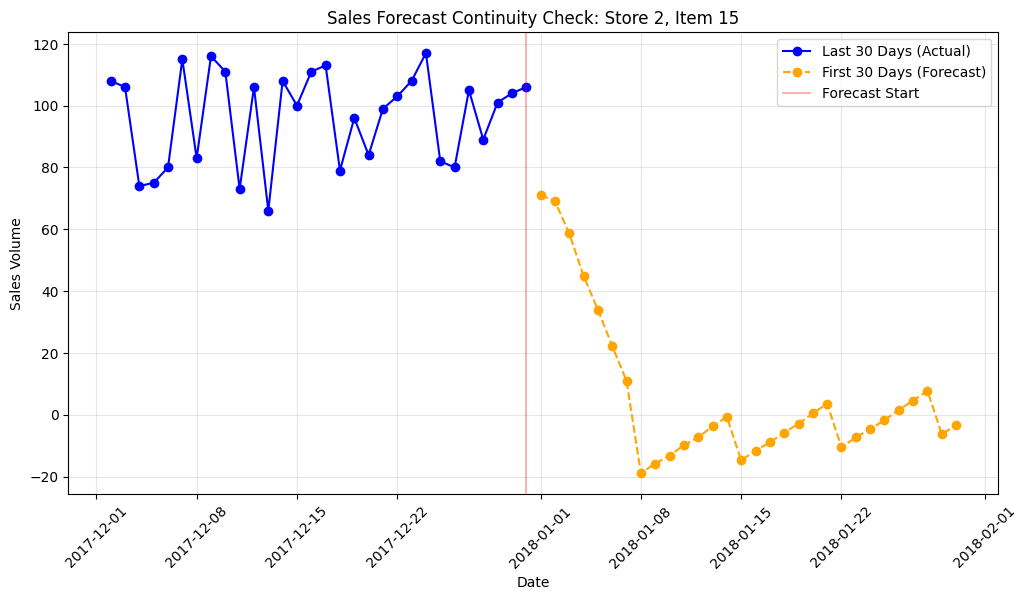

In [260]:
# 1. Grab the last 30 days of history for a specific store/item
history = Segmentation.tail(30)
actual_sales = history['sales']

# 2. Grab the first 30 days of predictions for the same store/item
# (Ensure your real_test_df has the 'predicted_sales' column we created)
future = test[(test['store'] == 2) & (test['item'] == 15)].head(30)

# 3. Plotting
plt.figure(figsize=(12, 6))

# Plot history in Blue
plt.plot(history['date'], actual_sales, label='Last 30 Days (Actual)', color='blue', marker='o')

# Plot forecast in Orange (starting from where history ends)
plt.plot(future['date'], future['predicted_sales'], label='First 30 Days (Forecast)', color='orange', linestyle='--', marker='o')

# Aesthetics
plt.axvline(x=history['date'].iloc[-1], color='red', linestyle='-', alpha=0.3, label='Forecast Start')
plt.title('Sales Forecast Continuity Check: Store 2, Item 15')
plt.xlabel('Date')
plt.ylabel('Sales Volume')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

My initial forecast shows the model is acting as a mean predictor, capturing the correct average volume but failing to propagate the weekly seasonality into the future.

Lets try Gradient Descent for coeffiecnt interpreation

In [261]:
from sklearn.linear_model import SGDRegressor

In [262]:
reg = SGDRegressor(max_iter=100,learning_rate='invscaling',eta0=0.0001)

In [263]:
reg.fit(X_train, y_train)

SGDRegressor(eta0=0.0001, max_iter=100)

In [264]:
reg.predict(X_test)

array([37.9190986 , 40.28607424, 47.37807468, ..., 56.75180953,
       56.92707364, 41.3813791 ])

In [265]:
r2_score(y_test, reg.predict(X_test))

0.9379027701506529

In [266]:
reg.coef_

array([ 2.71804755e-03, -1.50865294e-03, -8.01752586e-02,  1.49031183e-01,
        9.75793911e-03,  1.10172925e+00, -1.73429344e-01, -5.90449576e-02,
        1.11777565e+01, -6.68505062e-02,  2.41972381e+00,  2.54242612e-01,
       -3.79444115e-02])

In [267]:
X_train

,store,item,lag_sales_1,lag_sales_7,lag_sales_30,rolling_mean_7,rolling_mean_30,rolling_std_7,is_promotion,month,daysofweek,isWeekend,isHoliday
582865,10,32,26.0,32.0,32.0,32.000000,31.866667,8.869423,0,1,1,False,False
577771,7,32,23.0,18.0,21.0,21.000000,20.733333,4.690416,0,1,0,False,False
368140,2,21,44.0,34.0,31.0,42.857143,38.733333,8.764104,0,1,2,False,False
179776,9,10,81.0,90.0,81.0,87.428571,75.666667,13.023788,0,4,3,False,False
87159,8,5,23.0,30.0,41.0,28.000000,27.166667,5.537749,0,8,1,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
793868,5,44,36.0,24.0,31.0,26.000000,26.800000,5.163978,0,10,6,True,False
833170,7,46,51.0,50.0,42.0,43.714286,43.300000,6.156684,0,5,4,False,False
241359,3,14,59.0,59.0,61.0,56.428571,55.500000,11.487053,0,11,6,True,False
111719,2,7,71.0,76.0,71.0,63.428571,66.700000,6.051367,0,11,5,True,False


Fitting all the models again for coefficient

In [268]:
lr.fit(X_train_final,y_train)
reg.fit(X_train_final, y_train)


SGDRegressor(eta0=0.0001, max_iter=100)

In [269]:
lr.coef_

array([-8.20270118e-02,  1.50700409e-01,  8.51873791e-03,  1.10922057e+00,
       -1.85719411e-01, -6.14580402e-02,  1.13027511e+01, -5.61110856e-02,
        2.43699776e+00,  1.65680217e-01,  8.17211572e-02,  7.44776630e-02,
       -1.07628744e-01, -8.89147936e-02, -1.26897788e-01,  1.48903774e-01,
        6.29186846e-02,  9.55016423e-02,  3.72891397e-01,  1.46911495e-01,
       -3.40142147e-02, -6.15461506e-02,  2.87660851e-01,  3.34795925e-01,
        5.24011822e-01,  2.11725744e-01,  5.20261339e-01,  4.12085250e-01,
        3.66356160e-01,  4.96814421e-01,  3.29574328e-01,  6.50235796e-01,
       -1.73629629e-02,  1.04926965e-01,  5.91521746e-01,  1.80315749e-01,
        2.06699037e-01,  1.49200052e-01,  5.65668071e-01, -1.86263743e-02,
        3.80678562e-01,  5.49780192e-01,  2.57710104e-01, -1.19885085e-02,
        6.04478158e-01,  4.49880121e-01,  1.64062801e-01,  3.07898078e-01,
        2.22061336e-01,  4.04867960e-01,  1.69673097e-02,  3.89988595e-01,
        4.99847701e-01,  

In [270]:
reg.coef_

array([-8.12700829e-02,  1.54170848e-01,  1.39753092e-04,  1.10495858e+00,
       -1.88578016e-01, -7.10126992e-02,  1.12099879e+01, -6.25594702e-02,
        2.42282682e+00, -1.34008956e-01, -2.10404525e-01, -2.14918551e-01,
       -3.86505432e-01, -3.68598509e-01, -4.03297376e-01, -1.47185632e-01,
       -2.26795565e-01, -1.96456278e-01, -2.32511112e-02, -2.35515586e-01,
       -4.04110170e-01, -4.28316660e-01, -9.41376265e-02, -5.78325077e-02,
        1.22545678e-01, -1.65784459e-01,  1.14621360e-01,  1.84319620e-02,
       -1.84633727e-02,  1.03844199e-01, -6.11767072e-02,  2.35633125e-01,
       -3.83338708e-01, -2.75082147e-01,  1.84979335e-01, -2.04420545e-01,
       -1.76746446e-01, -2.30428374e-01,  1.59938965e-01, -3.80822008e-01,
       -9.83917352e-03,  1.45832233e-01, -1.34937738e-01, -3.83333188e-01,
        1.93333231e-01,  5.14072003e-02, -2.14506020e-01, -8.15456040e-02,
       -1.61130123e-01,  1.20377358e-02, -3.57169726e-01, -3.29813742e-03,
        9.97884978e-02, -

In [271]:
coef_df = pd.DataFrame({
    'Feature': X_train_final.columns,
    'GD_Coef': reg.coef_,
    'MLR_Coef': lr.coef_})
print(coef_df.sort_values(by='MLR_Coef', ascending=False).head(5))

           Feature    GD_Coef   MLR_Coef
6     is_promotion  11.209988  11.302751
8       daysofweek   2.422827   2.436998
3   rolling_mean_7   1.104959   1.109221
31         item_15   0.235633   0.650236
44         item_28   0.193333   0.604478


Interpretation:

*   When an item is on Promotion, we expect an imediate lift of approximately 11 units per day, holding all other factor constant. This tells us that our customers are highly responsive to marketing triggers. The promotion effect is nearly 5 times more powerful than the weekly cycle (daysofweek at 2.43).
*   The rolling_mean_7 coefficient of 1.11 is very significant. The model places a weight of 1.11 on the recent 7-day trend. This ensures the forecast stays grounded in the 'current' sales velocity rather than just jumping around based on holidays.
*   Item_15 (0.65) and Item_28 (0.60) are in top 5. Because these items have positive coefficients in the top 5, it indicates they are high-volume baseline items. They naturally sell more than the 'average' item in the catalog."
*   The model identifies Promotions as the most significant driver of demand, contributing an average lift of 11.3 units per day.
Beyond promotions, we see a strong Weekly Cycle (coefficient of 2.4) and a Momentum Effect where the 7-day rolling average provides the baseline for the forecast.
Finally, the model successfully distinguished high-performing products, like Item 15, which maintains a consistently higher baseline sales volume compared to the rest of the inventory.

**While I don't have a price column, my Promotion coefficient of 11.3 acts as a proxy for a price discount. It shows that when we effectively lower the 'entry price' through a promo, we see a massive volume lift, confirming our customers are highly price-sensitive.**






In [272]:
print(coef_df.sort_values(by='MLR_Coef', ascending=True).head(5))

            Feature   GD_Coef  MLR_Coef
4   rolling_mean_30 -0.188578 -0.185719
14          store_7 -0.403297 -0.126898
12          store_5 -0.386505 -0.107629
13          store_6 -0.368599 -0.088915
0       lag_sales_1 -0.081270 -0.082027


The negative coefficients provide a crucial check-and-balance for the model. For instance, Stores 5, 6, and 7 are identified as inherently lower-volume locations, allowing the model to shift its predictions down accordingly.
Most interestingly, the negative 30-day rolling mean acts as a stabilizer against the aggressive 7-day trend. This prevents the forecast from becoming overly 'optimistic' during short-term spikes and ensures the model reverts toward the long-term historical average.

In [273]:
from sklearn.preprocessing import FunctionTransformer
log_transformer = FunctionTransformer(np.log1p, validate=True)
X_train_scaled_ln = log_transformer.fit_transform(X_train_final)
X_test_scaled_ln = log_transformer.transform(X_test_final)

In [274]:
reg1 = SGDRegressor(max_iter=100,learning_rate='invscaling',eta0=0.0001)
reg1.fit(X_train_scaled_ln, y_train)
reg1.predict(X_test_scaled_ln)
r2_score(y_test, reg1.predict(X_test_scaled_ln))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


0.857595604447433

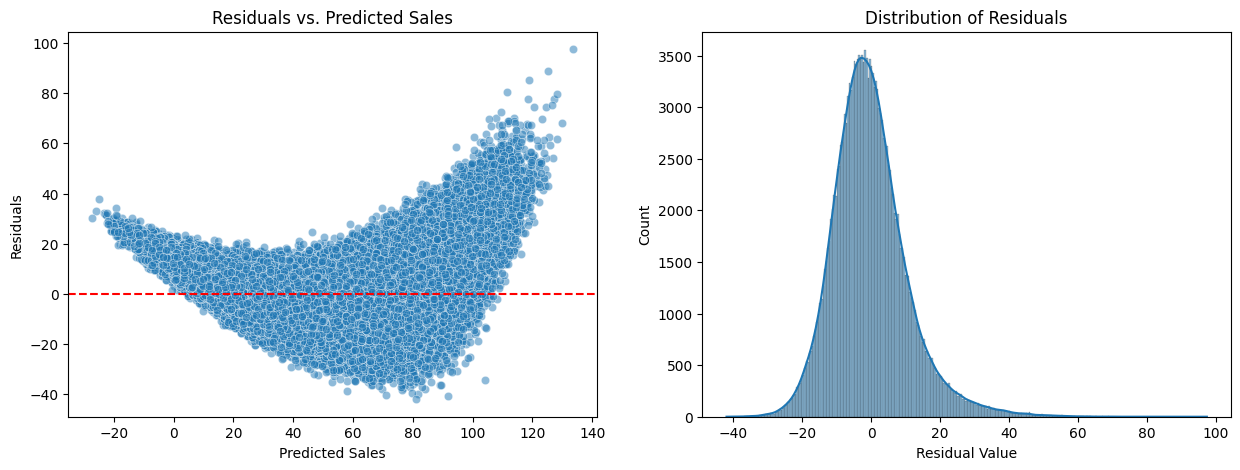

In [275]:
# log scaled data
import matplotlib.pyplot as plt
import seaborn as sns
residuals = y_test - reg1.predict(X_test_scaled_ln)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
# Plot 1: Residual vs Predicted (Check for Homoscedasticity)
sns.scatterplot(x=reg1.predict(X_test_scaled_ln), y=residuals, ax=ax1, alpha=0.5)
ax1.axhline(0, color='red', linestyle='--')
ax1.set_title('Residuals vs. Predicted Sales')
ax1.set_xlabel('Predicted Sales')
ax1.set_ylabel('Residuals')
# Plot 2: Histogram of Residuals (Check for Normality)
sns.histplot(residuals, kde=True, ax=ax2)
ax2.set_title('Distribution of Residuals')
ax2.set_xlabel('Residual Value')

plt.show()

In [276]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

In [277]:
reg2 = SGDRegressor(max_iter=100,learning_rate='invscaling',eta0=0.0001)
reg2.fit(X_train_scaled, y_train)
reg2.predict(X_test_scaled)
r2_score(y_test, reg2.predict(X_test_scaled))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


0.9369324725830366

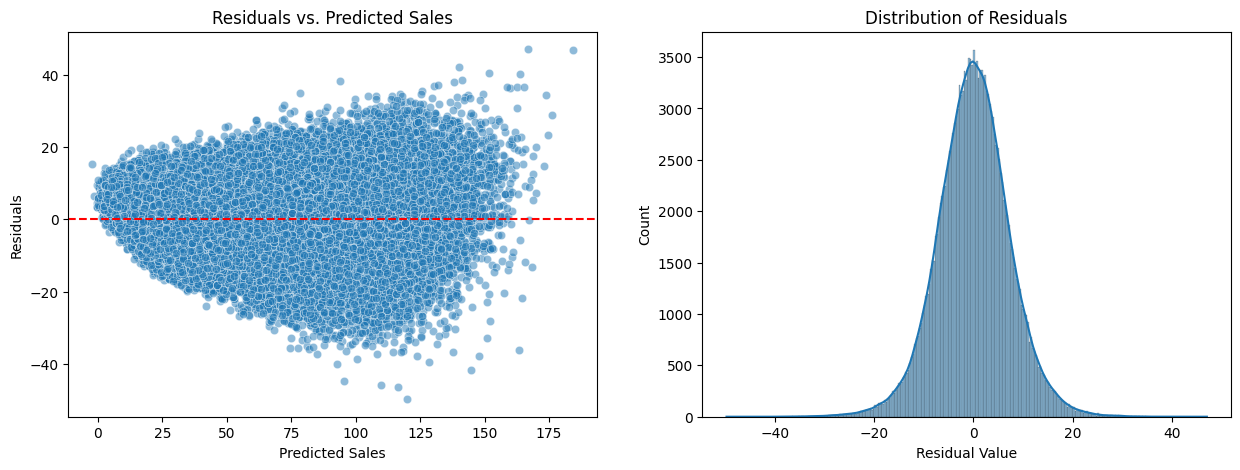

In [278]:
# Standard scaled data
import matplotlib.pyplot as plt
import seaborn as sns
residuals = y_test - reg2.predict(X_test_scaled)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
# Plot 1: Residual vs Predicted (Check for Homoscedasticity)
sns.scatterplot(x=reg2.predict(X_test_scaled), y=residuals, ax=ax1, alpha=0.5)
ax1.axhline(0, color='red', linestyle='--')
ax1.set_title('Residuals vs. Predicted Sales')
ax1.set_xlabel('Predicted Sales')
ax1.set_ylabel('Residuals')
# Plot 2: Histogram of Residuals (Check for Normality)
sns.histplot(residuals, kde=True, ax=ax2)
ax2.set_title('Distribution of Residuals')
ax2.set_xlabel('Residual Value')

plt.show()

1. Is Variance Constant? (Heteroscedasticity)
The Change: Look at the horizontal "spread" of the blue cloud. Compared to your Standard Scaler plot, the "fan" effect has been significantly reduced after the log transaformation. The dots are now more contained within a consistent vertical range across the X-axis.
Interpretation: "The log transformation successfully stabilized the variance (homoscedasticity). The model's error is no longer blowing up as sales volume increases, making our high-volume predictions much more reliable."
2. Any Visible Patterns?
The Verdict: A Strong "U-Shape" Curve.
The Observation: There is a very clear "smile" shape (parabolic curve) in the scatter plot.
The Interpretation: While the log fixed the variance, it revealed that the underlying relationship is not linear. The model is consistently over-predicting the "middle" range and under-predicting the "extremes."
3. Distribution of Residuals (The Histogram)
The Verdict: Slightly "Right-Skewed."
The Observation: The peak of the bell curve is still near zero, but the "tail" on the right side is longer than the one on the left.
The Interpretation: The model still struggles with those sudden, massive spikes (like major promotions or holidays). It tends to "under-predict" the biggest sales days.
4. The "Negative Prediction" Warning
Look at the X-axis: Your "Predicted Sales" go into the negative (down to -20).
The Catch: In the real world, you cannot sell -20 items.

Lets remove multicollinearity from the data.

In [279]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Convert boolean columns to integer (0 or 1)
X_train_numeric = X_train.copy()
X_train_numeric['isWeekend'] = X_train_numeric['isWeekend'].astype(int)
X_train_numeric['isHoliday'] = X_train_numeric['isHoliday'].astype(int)

vif = pd.DataFrame()
vif["Feature"] = X_train_numeric.columns
vif["VIF"] = [variance_inflation_factor(X_train_numeric.values, i) for i in range(X_train_numeric.shape[1])]

vif

,Feature,VIF
0,store,3.823886
1,item,3.439344
2,lag_sales_1,40.410209
3,lag_sales_7,50.004120
4,lag_sales_30,33.811069
5,rolling_mean_7,291.952152
6,rolling_mean_30,344.550450
7,rolling_std_7,16.479413
8,is_promotion,1.170090
9,month,5.116657


In [280]:
# Set the threshold for VIF
vif_threshold = 10

# Identify features with high VIF values
high_vif_features = vif[vif['VIF'] > vif_threshold]['Feature'].values

# Remove features with high VIF values from the dataset
df_filtered_vif = X_train_numeric.drop(high_vif_features, axis=1)

df_filtered_vif

,store,item,is_promotion,month,daysofweek,isWeekend,isHoliday
582865,10,32,0,1,1,0,0
577771,7,32,0,1,0,0,0
368140,2,21,0,1,2,0,0
179776,9,10,0,4,3,0,0
87159,8,5,0,8,1,0,0
...,...,...,...,...,...,...,...
793868,5,44,0,10,6,1,0
833170,7,46,0,5,4,0,0
241359,3,14,0,11,6,1,0
111719,2,7,0,11,5,1,0


In [281]:
X_test_numeric = X_test.copy()
X_test_numeric['isWeekend'] = X_test_numeric['isWeekend'].astype(int)
X_test_numeric['isHoliday'] = X_test_numeric['isHoliday'].astype(int)

vif_test = pd.DataFrame()
vif_test["Feature"] = X_test_numeric.columns
vif_test["VIF"] = [variance_inflation_factor(X_test_numeric.values, i) for i in range(X_test_numeric.shape[1])]

In [282]:
vif_threshold = 10

# Identify features with high VIF values
high_vif_test_features = vif_test[vif_test['VIF'] > vif_threshold]['Feature'].values

# Remove features with high VIF values from the dataset
df_filtered_vif_test = X_test_numeric.drop(high_vif_test_features, axis=1)

df_filtered_vif_test

,store,item,is_promotion,month,daysofweek,isWeekend,isHoliday
554356,4,31,0,12,1,0,0
118667,5,7,0,12,5,1,0
352984,4,20,0,7,0,0,0
445491,4,25,0,11,3,0,0
123565,8,7,0,5,6,1,0
...,...,...,...,...,...,...,...
427453,5,24,0,6,2,0,0
693050,10,38,0,9,3,0,0
771972,3,43,0,11,1,0,0
100315,5,6,0,9,4,0,0


In [283]:
lr.fit(df_filtered_vif,y_train)
reg.fit(df_filtered_vif, y_train)

SGDRegressor(eta0=0.0001, max_iter=100)

In [284]:
reg.predict(df_filtered_vif_test)
r2_score(y_test, reg.predict(df_filtered_vif_test))

0.06508953695486153

In [285]:
adjusted_r2 = 1 - (1 - r2_score(y_test, reg.predict(df_filtered_vif_test))) * (len(y_test) - 1) / (len(y_test) - df_filtered_vif_test.shape[1] - 1)
adjusted_r2

0.06505309672789528

In [286]:
print("RMSE for train",np.sqrt(mean_squared_error(y_train,reg.predict(df_filtered_vif))))

RMSE for train 27.870000593524253


In [287]:
print("RMSE for test",np.sqrt(mean_squared_error(y_test,reg.predict(df_filtered_vif_test))))

RMSE for test 27.906347453409982


In [288]:
lr.predict(df_filtered_vif_test)
r2_score(y_test, lr.predict(df_filtered_vif_test))

0.06517724591980023

Looks like after removing the multicollinearity in the data, R2 Score and asjusted R2 decreased to 0.05 from 0.93. While (RMSE) increased from 7 to 28. Clearly removing the correlated features in not helping to predict the model.

In [289]:
coef_df = pd.DataFrame({
    'Feature': df_filtered_vif.columns,
    'GD_Coef': reg.coef_,
    'MLR_Coef': lr.coef_})
print(coef_df.sort_values(by='MLR_Coef', ascending=False).head())

        Feature   GD_Coef   MLR_Coef
2  is_promotion  9.841437  10.030257
4    daysofweek  2.973507   2.929164
3         month  0.629182   0.603295
0         store -0.104303  -0.079052
1          item -0.102130  -0.112654


Interpretation:
Looks like even though R2 Score is decreased and RMSE is increased coefficients for is_promotion and days of week comes out to be similar to what we calculated before removing multicollinearity means those two are the most effective features of the data.
When an item is on Promotion, we expect an imediate lift of approximately 10 units per day, holding all other factor constant. This tells us that our customers are highly responsive to marketing triggers. The promotion effect is nearly 3.33 times more powerful than the weekly cycle (daysofweek at 3).